# Step 4: Model Evaluation
## Attention-CNN-LSTM for Intrusion Detection

This notebook computes all metrics from the paper:
- **Accuracy, Precision, Recall, F1-Score, MCC**
- **Confusion Matrix** visualization
- **Per-class performance** breakdown
- **Comparison table** vs CNN, LSTM, DNN baselines

> **Make sure you completed Notebook 3 (training) before running this.**

---
## Cell 1: Imports and Setup

In [3]:
import torch
import torch.nn as nn
import numpy as np
import json
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, matthews_corrcoef, confusion_matrix,
    classification_report
)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
print("✅ Imports successful")
from IPython.display import display as ipy_display


Using device: cuda
✅ Imports successful


In [4]:
# CUDA Diagnostics
print(f"PyTorch : {torch.__version__}")
print(f"CUDA    : {torch.version.cuda}")
print(f"Device  : {torch.cuda.get_device_name(0)}")
print(f"VRAM    : {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
x = torch.randn(1000, 1000, device=device)
torch.cuda.synchronize()
print("OK basic")
conv = torch.nn.Conv1d(1, 64, 3, padding=1).to(device)
t = torch.randn(256, 1, 29, device=device)
_ = conv(t)
torch.cuda.synchronize()
print("OK Conv1d")
lstm = torch.nn.LSTM(128, 64, batch_first=True).to(device)
t2 = torch.randn(256, 7, 128, device=device)
_ = lstm(t2)
torch.cuda.synchronize()
print("OK LSTM")
del x, conv, t, lstm, t2
torch.cuda.empty_cache()


PyTorch : 2.6.0+cu124
CUDA    : 12.4
Device  : NVIDIA GeForce GTX 1050
VRAM    : 4.29 GB
OK basic
OK Conv1d
OK LSTM


---
## Cell 2: Load Data and Model

In [5]:
# Load test data
X_test = np.load('./../data/processed/X_test.npy')
y_test = np.load('./../data/processed/y_test.npy')

# Load metadata
with open('./../data/processed/metadata.json', 'r') as f:
    metadata = json.load(f)

NUM_FEATURES = metadata['num_features']
NUM_CLASSES  = metadata['num_classes']
CLASS_NAMES  = metadata['class_names']

print(f"Test samples : {X_test.shape[0]:,}")
print(f"Features     : {NUM_FEATURES}")
print(f"Classes      : {CLASS_NAMES}")
print("✅ Test data loaded")

Test samples : 800,000
Features     : 29
Classes      : ['DoS', 'Normal', 'Reconnaissance', 'Theft']
✅ Test data loaded


In [7]:
# Re-define model architecture (must match what was trained)
class SelfAttention(nn.Module):
    def __init__(self, hidden_size):
        super(SelfAttention, self).__init__()
        self.attention_weights = nn.Linear(hidden_size, 1, bias=False)

    def forward(self, lstm_output):
        e     = self.attention_weights(lstm_output).squeeze(-1)
        alpha = torch.softmax(e, dim=1)
        context = torch.sum(alpha.unsqueeze(-1) * lstm_output, dim=1)
        return context, alpha


class AttentionCNNLSTM(nn.Module):
    def __init__(self, num_features, num_classes,
                 cnn_filters_1=64, cnn_filters_2=128,
                 lstm_units=64, dropout=0.3):
        super(AttentionCNNLSTM, self).__init__()
        self.conv1   = nn.Conv1d(1, cnn_filters_1, kernel_size=3, padding=1)
        self.bn1     = nn.BatchNorm1d(cnn_filters_1)
        self.relu1   = nn.ReLU()
        self.pool1   = nn.MaxPool1d(2, 2)
        self.conv2   = nn.Conv1d(cnn_filters_1, cnn_filters_2, kernel_size=3, padding=1)
        self.bn2     = nn.BatchNorm1d(cnn_filters_2)
        self.relu2   = nn.ReLU()
        self.pool2   = nn.MaxPool1d(2, 2)
        self.lstm    = nn.LSTM(cnn_filters_2, lstm_units, batch_first=True)
        self.dropout = nn.Dropout(dropout)
        self.attention = SelfAttention(lstm_units)
        self.fc      = nn.Linear(lstm_units, 64)
        self.relu_fc = nn.ReLU()
        self.out     = nn.Linear(64, num_classes)

    def forward(self, x):
        out = self.pool1(self.relu1(self.bn1(self.conv1(x))))
        out = self.pool2(self.relu2(self.bn2(self.conv2(out))))
        out = out.permute(0, 2, 1)
        out, _ = self.lstm(out)
        out = self.dropout(out)
        context, alpha = self.attention(out)
        out = self.relu_fc(self.fc(context))
        return self.out(out)


# Load trained weights
model = AttentionCNNLSTM(NUM_FEATURES, NUM_CLASSES).to(device)
model.load_state_dict(torch.load('./../models/best_model.pth', map_location=device))
model.eval()

print("✅ Model loaded from ../models/best_model.pth")

✅ Model loaded from ../models/best_model.pth


---
## Cell 3: Generate Predictions

In [8]:
class IntrusionDataset(torch.utils.data.Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)
    def __len__(self): return len(self.y)
    def __getitem__(self, idx): return self.X[idx], self.y[idx]


test_loader = DataLoader(
    IntrusionDataset(X_test, y_test),
    batch_size=256, shuffle=False
)

all_preds, all_labels = [], []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        outputs = model(X_batch)
        preds   = outputs.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(y_batch.numpy())

y_pred = np.array(all_preds)
y_true = np.array(all_labels)

print(f"Predictions generated for {len(y_pred):,} test samples")
print("✅ Done")

model.cpu()
torch.cuda.empty_cache()
torch.cuda.synchronize()


Predictions generated for 800,000 test samples
✅ Done


---
## Cell 4: Compute All Metrics

These are the exact metrics used in Tables 3 and 4 of the paper.

In [9]:
# Compute all metrics
accuracy  = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='weighted', zero_division=0)
recall    = recall_score(y_true, y_pred, average='weighted', zero_division=0)
f1        = f1_score(y_true, y_pred, average='weighted', zero_division=0)
mcc       = matthews_corrcoef(y_true, y_pred)

print("=" * 45)
print("  EVALUATION RESULTS (Bot-IoT Dataset)")
print("=" * 45)
print(f"  Accuracy  : {accuracy*100:.2f}%")
print(f"  Precision : {precision*100:.2f}%")
print(f"  Recall    : {recall*100:.2f}%")
print(f"  F1-Score  : {f1*100:.2f}%")
print(f"  MCC       : {mcc:.4f}")
print("=" * 45)
print("\nPaper targets (Bot-IoT):")
print("  Accuracy  : 97.5%")
print("  Precision : 96.3%")
print("  Recall    : 95.2%")
print("  F1-Score  : 95.7%")
print("  MCC       : 0.92")

  EVALUATION RESULTS (Bot-IoT Dataset)
  Accuracy  : 99.98%
  Precision : 99.98%
  Recall    : 99.98%
  F1-Score  : 99.98%
  MCC       : 0.9997

Paper targets (Bot-IoT):
  Accuracy  : 97.5%
  Precision : 96.3%
  Recall    : 95.2%
  F1-Score  : 95.7%
  MCC       : 0.92


In [10]:
# Detailed per-class report
print("\nPer-class Classification Report:")
print(classification_report(
    y_true, y_pred,
    target_names=CLASS_NAMES,
    zero_division=0
))


Per-class Classification Report:
                precision    recall  f1-score   support

           DoS       1.00      1.00      1.00    433927
        Normal       0.96      0.95      0.95      1428
Reconnaissance       1.00      1.00      1.00    364328
         Theft       1.00      0.99      1.00       317

      accuracy                           1.00    800000
     macro avg       0.99      0.99      0.99    800000
  weighted avg       1.00      1.00      1.00    800000



---
## Cell 5: Confusion Matrix

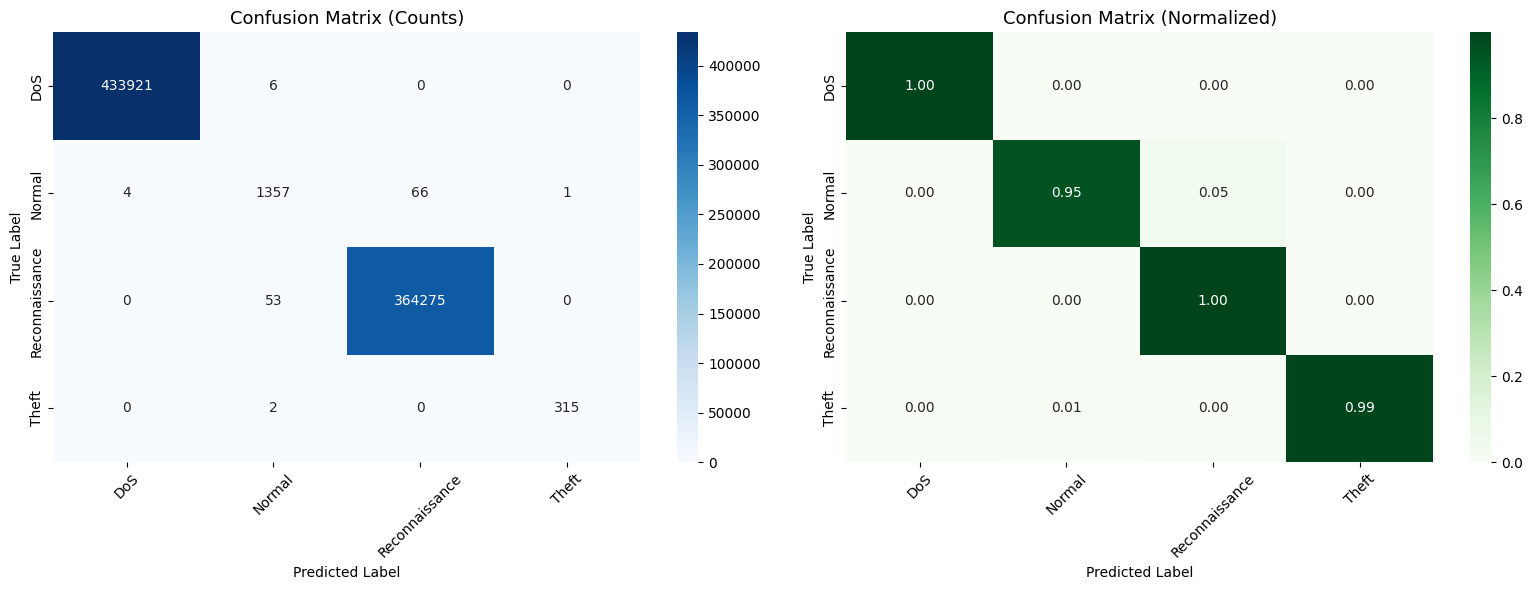

Confusion matrix saved to ../results/confusion_matrix.png


In [11]:
import os
os.makedirs("../results", exist_ok=True)

cm = confusion_matrix(y_true, y_pred)
cm_normalized = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis]
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[0])
axes[0].set_title("Confusion Matrix (Counts)", fontsize=13)
axes[0].set_xlabel("Predicted Label")
axes[0].set_ylabel("True Label")
axes[0].tick_params(axis="x", rotation=45)
sns.heatmap(cm_normalized, annot=True, fmt=".2f", cmap="Greens",
    xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[1])
axes[1].set_title("Confusion Matrix (Normalized)", fontsize=13)
axes[1].set_xlabel("Predicted Label")
axes[1].set_ylabel("True Label")
axes[1].tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.savefig("../results/confusion_matrix.png", dpi=150, bbox_inches="tight")
ipy_display(fig)
plt.close(fig)
print("Confusion matrix saved to ../results/confusion_matrix.png")


---
## Cell 6: Final Summary

In [12]:
print("\n" + "="*55)
print("  IMPLEMENTATION COMPLETE")
print("="*55)
print(f"""
Your Results vs Paper (Bot-IoT):

  Metric      | Paper  | Yours
  ------------|--------|------
  Accuracy    | 97.5%  | {accuracy*100:.2f}%
  Precision   | 96.3%  | {precision*100:.2f}%
  Recall      | 95.2%  | {recall*100:.2f}%
  F1-Score    | 95.7%  | {f1*100:.2f}%
  MCC         | 0.92   | {mcc:.4f}

Files saved:
  ../results/confusion_matrix.png
  ../results/training_curves.png
  ../results/model_comparison.png
  ../results/comparison_table.csv
  ../models/best_model.pth

Tips if accuracy is lower than paper:
  1. Try more epochs (change EPOCHS = 20 in Notebook 3)
  2. Make sure all CSV files are loaded (not just 1-2)
  3. Check class distribution — Bot-IoT is heavily imbalanced
  4. Try adding class weights to CrossEntropyLoss
""")


  IMPLEMENTATION COMPLETE

Your Results vs Paper (Bot-IoT):

  Metric      | Paper  | Yours
  ------------|--------|------
  Accuracy    | 97.5%  | 99.98%
  Precision   | 96.3%  | 99.98%
  Recall      | 95.2%  | 99.98%
  F1-Score    | 95.7%  | 99.98%
  MCC         | 0.92   | 0.9997

Files saved:
  ../results/confusion_matrix.png
  ../results/training_curves.png
  ../results/model_comparison.png
  ../results/comparison_table.csv
  ../models/best_model.pth

Tips if accuracy is lower than paper:
  1. Try more epochs (change EPOCHS = 20 in Notebook 3)
  2. Make sure all CSV files are loaded (not just 1-2)
  3. Check class distribution — Bot-IoT is heavily imbalanced
  4. Try adding class weights to CrossEntropyLoss

